In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# default simulation parameters

a = 0.5  # 
b = 0.1  # 
r = 0.1  # 
dt = 1e-3
T = 300

In [3]:

# --- FHN Model Simulation Function ---

def fhn_euler(v0, w0, I_ext, a, b, r, dt, T):
    """
    Simulates the FitzHugh-Nagumo model using Euler's method.

    Args:
        v0 (float): Initial membrane potential.
        w0 (float): Initial recovery variable.
        I_ext (float): External stimulus current.
        a, b, r (float): Model parameters.
        dt (float): Time step for the simulation.
        T (float): Total simulation time.

    Returns:
        tuple: A tuple containing time, V, and W arrays.
    """
    # Create time array
    t = np.arange(0, T, dt)
    # Initialize V and W arrays as zeros of the same length as t
    v = np.zeros_like(t)
    w = np.zeros_like(t)
    # Set initial conditions
    v[0] = v0
    w[0] = w0

    # Euler method implementation
    for i in range(len(t) - 1):
        # dv/dt = v(a-v)(v-1) - w + I_ext
        dvdt = v[i] * (a - v[i]) * (v[i] - 1) - w[i] + I_ext
        # dw/dt = b*v - r*w (Corrected equation)
        dwdt = b * v[i] - r * w[i]
        
        v[i+1] = v[i] + dt * dvdt
        w[i+1] = w[i] + dt * dwdt
        
    return t, v, w



In [4]:
# --- Helper Plotting Functions ---

def plot_phase_plane(ax, a, b, r, I_ext,  xlim = (-0.5, 1.5), ylim = (-1.5, 1.5)):
    """Plots the nullclines and vector field on a given axis."""
    # Define the grid for the vector field
    v_range = np.linspace(-1.5, 1.5, 50)
    w_range = np.linspace(-1.5, 1.5, 50)
    V_grid, W_grid = np.meshgrid(v_range, w_range)

    # Calculate the derivatives at each grid point
    dVdt = V_grid * (a - V_grid) * (V_grid - 1) - W_grid + I_ext
    dWdt = b * V_grid - r * W_grid
    
    # Plot the vector field
    ax.quiver(V_grid, W_grid, dVdt, dWdt, color='gray')

    # Plot the nullclines
    v_nullcline_v = np.linspace(-0.5, 1.5, 100)
    # v-nullcline: dv/dt = 0 => w = v(a-v)(v-1) + I_ext
    v_nullcline_w = v_nullcline_v * (a - v_nullcline_v) * (v_nullcline_v - 1) + I_ext
    # w-nullcline: dw/dt = 0 => w = (b/r)*v
    w_nullcline_w = (b / r) * v_nullcline_v
    
    ax.plot(v_nullcline_v, v_nullcline_w, 'b-', label='v-nullcline (dv/dt=0)')
    ax.plot(v_nullcline_v, w_nullcline_w, 'r-', label='w-nullcline (dw/dt=0)')
    
    ax.set_xlabel('Membrane Potential (V)')
    ax.set_ylabel('Recovery Variable (W)')
    ax.set_title(f'Phase Plane (I_ext = {I_ext})')
    ax.legend()
    ax.grid(True)
    ax.set_xlim([ xlim[0], xlim[1]])
    ax.set_ylim([ ylim[0], ylim[1]])



In [5]:
def plot_time_series(ax, t, v, w, title):
    """Plots the V(t) and W(t) time series on a given axis."""
    ax.plot(t, v, label='V(t)')
    ax.plot(t, w, label='W(t)')
    ax.set_xlabel('Time (t)')
    ax.set_ylabel('State Variables')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


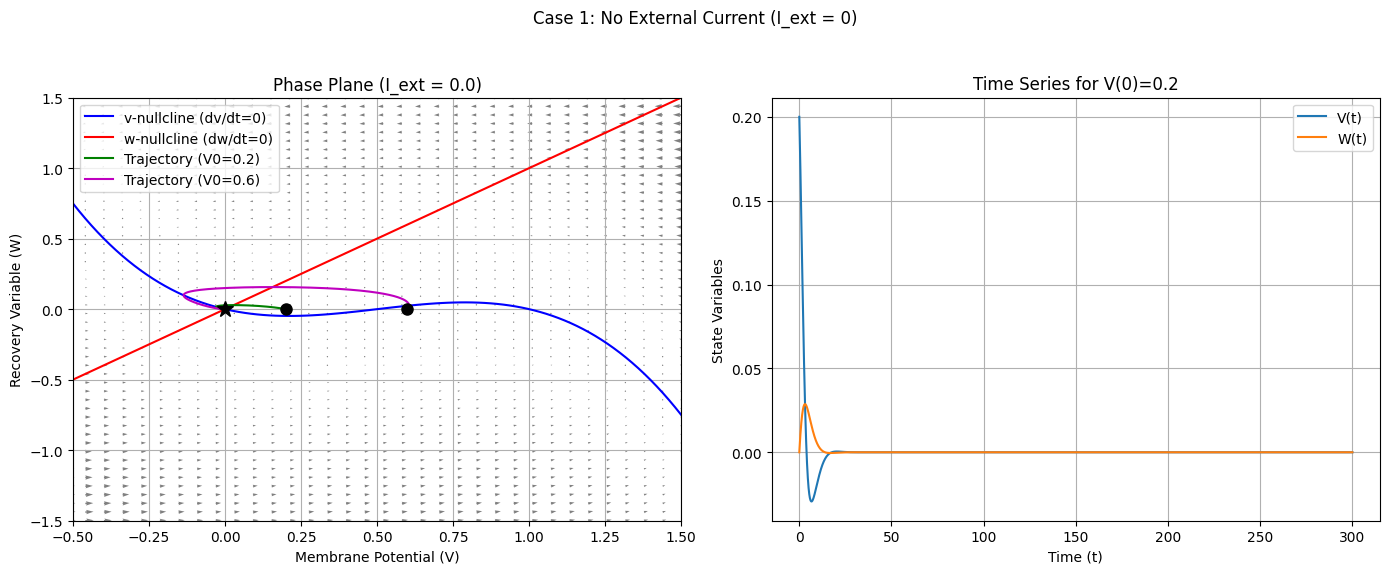

In [6]:
# --- Case 1: I_ext = 0 ---
I_ext_1 = 0.0 # No external current

# Initial conditions | a = 0.5

# i. V(0) < a and W(0) = 0
v0_1i, w0_1i = 0.2, 0.0 #  Voltage like variable (proxy for voltage), Recovery like variable 

# ii. V(0) > a and W(0) = 0
v0_1ii, w0_1ii = 0.6, 0.0 # 

# Run simulations
t1i, v1i, w1i = fhn_euler(v0_1i, w0_1i, I_ext_1, a, b, r, dt, T) 
t1ii, v1ii, w1ii = fhn_euler(v0_1ii, w0_1ii, I_ext_1, a, b, r, dt, T)

# Plotting
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 6))
# a. Phase plot
plot_phase_plane(ax1a, a, b, r, I_ext_1)
ax1a.plot(v1i, w1i, 'g-', label=f'Trajectory (V0={v0_1i})')
ax1a.plot(v1ii, w1ii, 'm-', label=f'Trajectory (V0={v0_1ii})')
ax1a.plot([v0_1i, v0_1ii], [w0_1i, w0_1ii], 'ko', markersize=8) # Start points
ax1a.plot(0, 0, 'k*', markersize=12) # End point (Fixed Point)
ax1a.legend()

# b. Time series plots
plot_time_series(ax1b, t1i, v1i, w1i, f'Time Series for V(0)={v0_1i}')
plt.suptitle("Case 1: No External Current (I_ext = 0)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [10]:
def calculate_fhn_bifurcations_analytical(a, b, r):
    """
    Calculates the exact Hopf bifurcation points (I1, I2) for the FHN model.
    """
    # The bifurcation occurs when the trace of the Jacobian is zero:
    # when trace is zero, no real part. Trace > 0 means unstable , Trace < 0 means stable
    # 3v^2 - 2(1+a)v + (a+r) = 0
    # We solve this quadratic equation for v.
    coeffs = [3, -2 * (1 + a), a + r]
    v_bifurcation_points = np.roots(coeffs)
    v1 = min(v_bifurcation_points)
    v2 = max(v_bifurcation_points)

    # Now, find the I_ext that corresponds to each v value using the
    # nullcline intersection equation: I_ext = (b/r)v - v(a-v)(v-1)
    def find_I(v, a, b, r):
        return (b / r) * v - (v * (a - v) * (v - 1))

    I1 = find_I(v1, a, b, r)
    I2 = find_I(v2, a, b, r)
    
    return I1, I2

# --- Run the Analytical Calculation ---
I1_ana, I2_ana = calculate_fhn_bifurcations_analytical(a, b, r)

print(f"--- Analytical Calculation Results ---")
print(f"The lower limit I1 to have unstable point is: {I1_ana:.6f}")
print(f"The upper limit for the value of I2 for unstable point is: {I2_ana:.6f}")

--- Analytical Calculation Results ---
The lower limit I1 to have unstable point is: 0.321115
The upper limit for the value of I2 for unstable point is: 0.678885


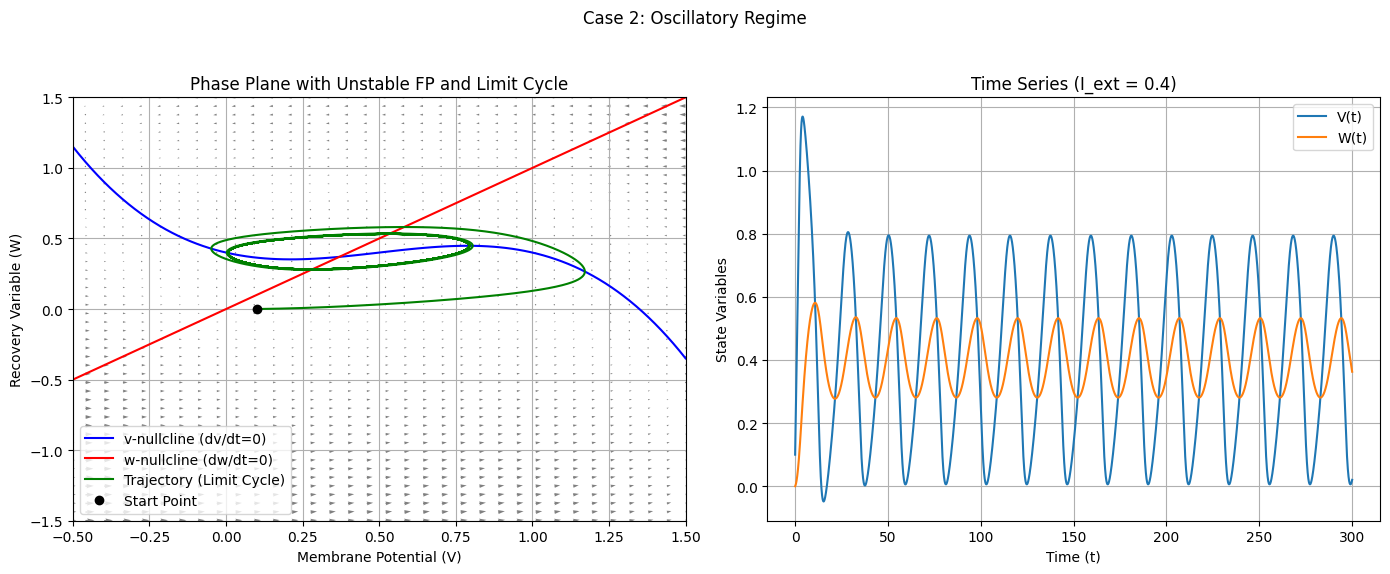

In [7]:
I_ext_2 = 0.4 # Sample value in acceptable range 
v0_2, w0_2 = 0.1, 0.0 # Perturbation near the fixed point

# Run simulation
t2, v2, w2 = fhn_euler(v0_2, w0_2, I_ext_2, a, b, r, dt, T)

# Plotting
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 6))
# a, b. Phase plot with unstable fixed point and limit cycle
plot_phase_plane(ax2a, a, b, r, I_ext_2)
ax2a.plot(v2, w2, 'g-', label='Trajectory (Limit Cycle)')
ax2a.plot(v0_2, w0_2, 'ko', markersize=6, label='Start Point')

ax2a.set_title('Phase Plane with Unstable FP and Limit Cycle')
ax2a.legend()
# c. Time series plot
plot_time_series(ax2b, t2, v2, w2, f'Time Series (I_ext = {I_ext_2})')
plt.suptitle("Case 2: Oscillatory Regime")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Running Case 3...


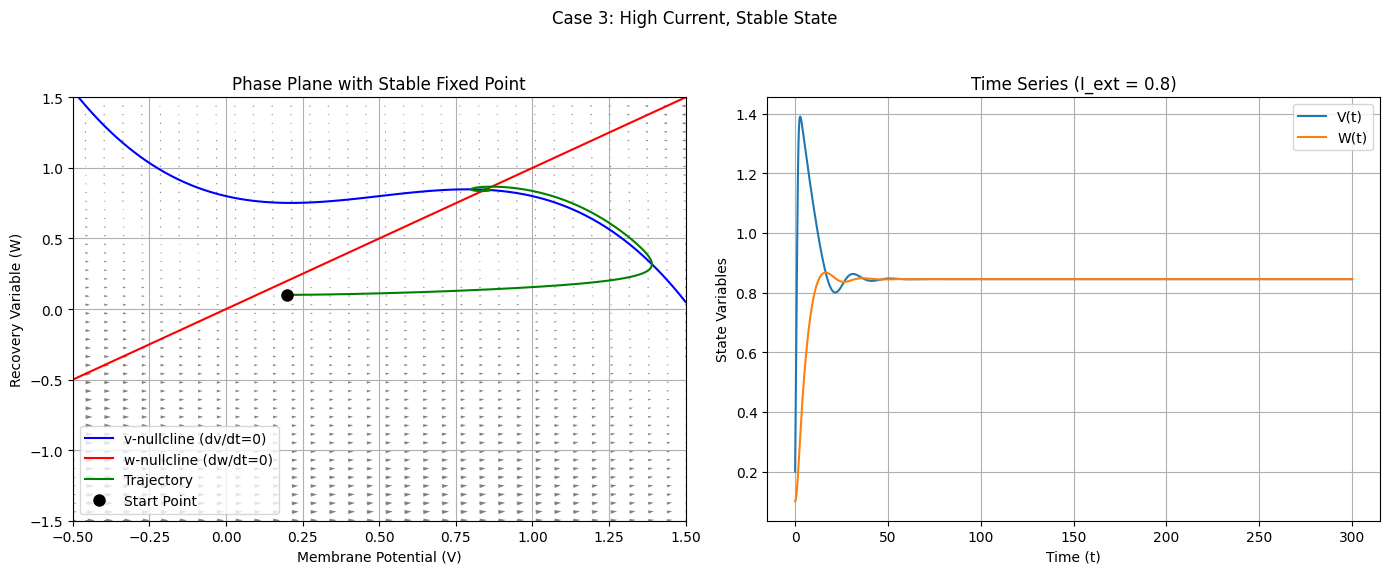

In [9]:

# --- Case 3: Stable High-Voltage State (I_ext > I2) ---
print("Running Case 3...")
I_ext_3 = 0.8 # Sample value > I2 
v0_3, w0_3 = 0.2, 0.1 # Perturbation

# Run simulation
t3, v3, w3 = fhn_euler(v0_3, w0_3, I_ext_3, a, b, r, dt, T)

# Plotting
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))
# a, b. Phase plot showing stable fixed point
plot_phase_plane(ax3a, a, b, r, I_ext_3)
ax3a.plot(v3, w3, 'g-', label='Trajectory')
ax3a.plot(v0_3, w0_3, 'ko', markersize=8, label='Start Point')
ax3a.set_title('Phase Plane with Stable Fixed Point')
ax3a.legend()
# c. Time series plot
plot_time_series(ax3b, t3, v3, w3, f'Time Series (I_ext = {I_ext_3})')
plt.suptitle("Case 3: High Current, Stable State")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



In [11]:
# --- Case 4: Bistability ---
print("Running Case 4...")
# New parameters to achieve bistability 
I_ext_4 = 0.05 # Midway in the bistable range
b_4 = 0.01
r_4 = 0.1 

# Initial conditions to show stability of different fixed points
v0_p1, w0_p1 = -0.1, -0.05 # Near P1 (stable)
v0_p2, w0_p2 = 0.25, 0.05  # Near P2 (unstable)
v0_p3, w0_p3 = 0.8, 0.15   # Near P3 (stable)


Running Case 4...


Running Case 4...


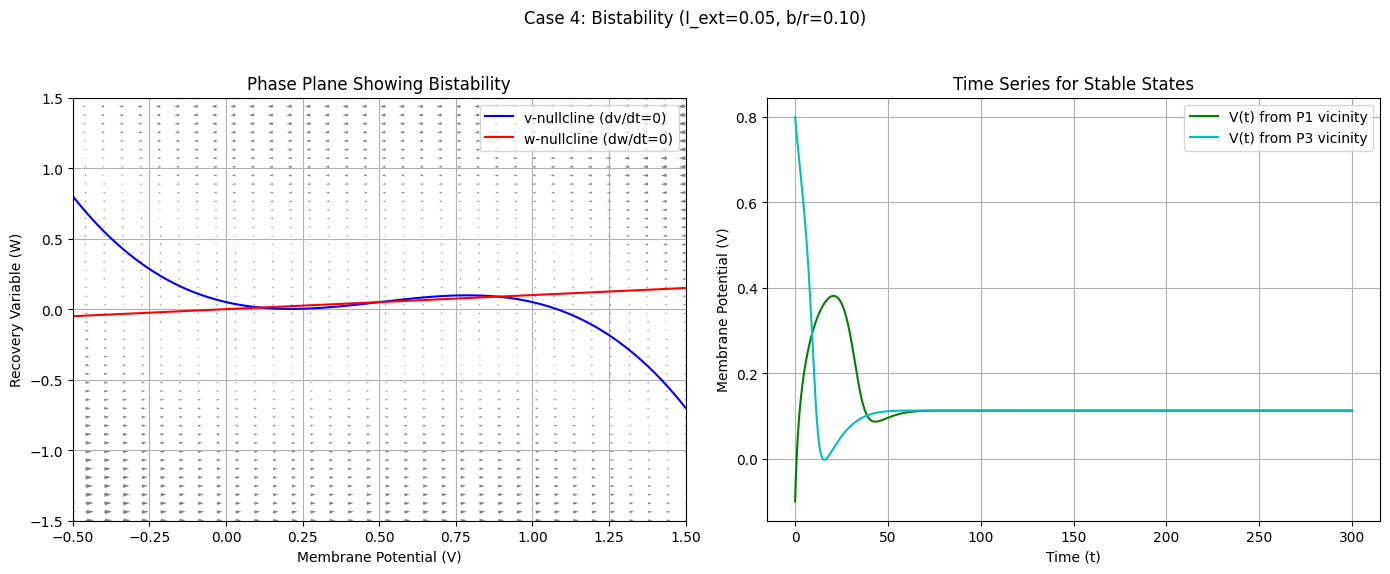

In [14]:
# --- Case 4: Bistability ---
print("Running Case 4...")
# New parameters to achieve bistability 
I_ext_4 = 0.05 # Midway in the bistable range
b_4 = 0.01
r_4 = 0.1 

# Initial conditions to show stability of different fixed points
v0_p1, w0_p1 = -0.1, -0.05 # Near P1 (stable)
v0_p2, w0_p2 = 0.25, 0.05  # Near P2 (unstable)
v0_p3, w0_p3 = 0.8, 0.15   # Near P3 (stable)

# Run simulations
t4_p1, v4_p1, w4_p1 = fhn_euler(v0_p1, w0_p1, I_ext_4, a, b_4, r_4, dt, T)
t4_p2, v4_p2, w4_p2 = fhn_euler(v0_p2, w0_p2, I_ext_4, a, b_4, r_4, dt, T)
t4_p3, v4_p3, w4_p3 = fhn_euler(v0_p3, w0_p3, I_ext_4, a, b_4, r_4, dt, T)

# Plotting
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6))

# a, b. Phase plot showing bistability
plot_phase_plane(ax4a, a, b_4, r_4, I_ext_4)
# ax4a.plot(v4_p1, w4_p1, 'g-', label='Trajectory to P1')
# ax4a.plot(v4_p2, w4_p2, 'm-', label='Trajectory from P2')
# ax4a.plot(v4_p3, w4_p3, 'c-', label='Trajectory to P3')
ax4a.set_title('Phase Plane Showing Bistability')
ax4a.legend()


# c. Time series plots
ax4b.plot(t4_p1, v4_p1, 'g-', label=f'V(t) from P1 vicinity')
ax4b.plot(t4_p3, v4_p3, 'c-', label=f'V(t) from P3 vicinity')
ax4b.set_xlabel('Time (t)')
ax4b.set_ylabel('Membrane Potential (V)')
ax4b.set_title('Time Series for Stable States')
ax4b.legend()
ax4b.grid(True)
plt.suptitle(f"Case 4: Bistability (I_ext={I_ext_4}, b/r={b_4/r_4:.2f})")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()